In [6]:
import sys
import os
from typing import Counter
from refactoring_benchmark.utils.common import load_instances_from_csv
import matplotlib.pyplot as plt

path_to_add = os.path.abspath("..")
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

In [7]:
instances = load_instances_from_csv("../instances.csv")

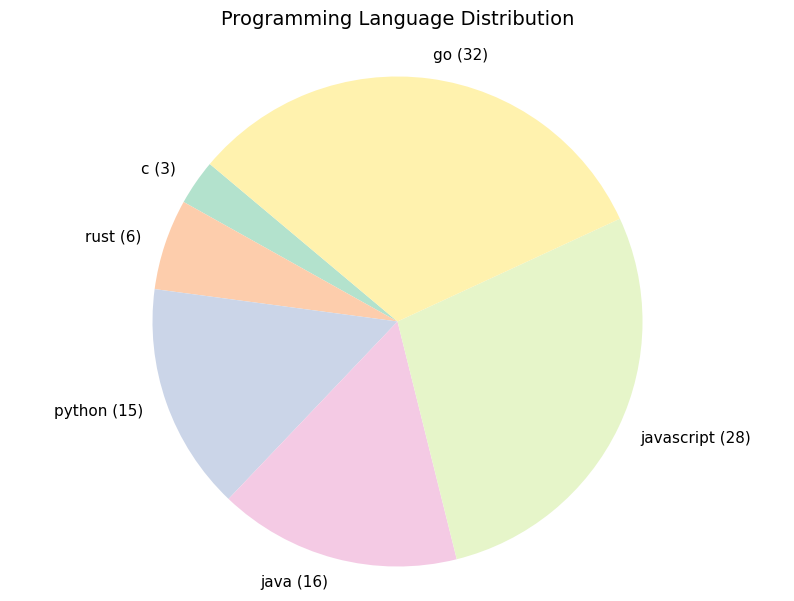

In [8]:



lang_counts = Counter([inst.language for inst in instances])
# 3. Sort data by count for a cleaner look
sorted_langs = sorted(lang_counts.items(), key=lambda item: item[1])
labels_raw, values = zip(*sorted_langs)

# 4. Format labels (e.g., "go (3)")
labels = [f"{lang} ({count})" for lang, count in zip(labels_raw, values)]

# 5. Plotting
plt.figure(figsize=(10, 7))

# Using a varied color palette
colors = plt.cm.Pastel2(range(len(labels)))

plt.pie(
    values, 
    labels=labels, 
    colors=colors, 
    startangle=140,
    textprops={'fontsize': 11}
)

plt.title("Programming Language Distribution", fontsize=14, pad=20)
plt.axis('equal') 

plt.show()

In [12]:
import pandas as pd
from unidiff import PatchSet


def get_diff_stats(file_path):
    """
    Parses a unified diff file.
    Returns: (number_of_files, total_lines_edited)
    """
    if not os.path.exists(file_path):
        return None

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            patch = PatchSet(f)
        
        num_files = len(patch)
        lines_edited = sum(p.added + p.removed for p in patch)
        lines_added = sum(p.added for p in patch)
        lines_removed = sum(p.removed for p in patch)
        return num_files, lines_edited, lines_added, lines_removed
    except Exception as e:
        # Handle potential encoding or parsing errors
        return None

# 2. Collect stats for all instances
stats_list = []

for inst in instances:
    # Generalize path: ../assets/diffs/{owner}/{repo}/{short_hash}/golden.diff
    short_hash = inst.commit_hash[:8]
    diff_path = os.path.join("..", "assets", "diffs", inst.owner, inst.repo, short_hash, "golden.diff")
    
    result = get_diff_stats(diff_path)
    
    if result:
        files, lines, lines_added, lines_removed = result
        stats_list.append({
            'Files Changed': files,
            'Lines Edited': lines,
            'Lines Added': lines_added,
            'Lines Removed': lines_removed
        })

# 3. Create DataFrame and compute statistics
df = pd.DataFrame(stats_list)

# Calculate summary stats
summary_table = df.agg(['max', 'min', 'mean', 'median']).transpose()

# 4. Print the table
print("Github API shows binary files. Unified diff parser skips them. That's why here min is 36.")
print("Statistics for 100 Instances:")
print("=" * 30)
print(summary_table.to_string())

Github API shows binary files. Unified diff parser skips them. That's why here min is 36.
Statistics for 100 Instances:
                   max    min     mean  median
Files Changed    290.0   36.0    91.52    73.0
Lines Edited   18821.0  254.0  2605.39  1515.5
Lines Added     7172.0   95.0  1190.33   743.0
Lines Removed  11649.0   72.0  1415.06   718.0


In [14]:
# stats on agents
import os
import pandas as pd
from unidiff import PatchSet

# 1. Define your dimensions
modes = [
    "output", "output_abstract", "output_abstract_multiplan", 
    "output_abstract_plan", "output_open", "output_pseudo_agents"
]

agents = [
    "claude-code-v2.0.76-sonnet45",
    "codex-v0.77.0-gpt-5.1-codex-mini",
    "codex-v0.77.0-gpt-5.2",
    "golden_agent",
    "null_agent"
]

all_stats = []

# 2. Nested loop to traverse the filesystem
for mode in modes:
    for agent in agents:
        print("\nX", end="")
        for inst in instances:
            print(".", end="")
            short_hash = inst.commit_hash[:8]
            
            # Construct path to prediction.diff
            # Path: ../{mode}/{owner}/{repo}/{short_hash}/{agent}/prediction.diff
            diff_path = os.path.join("..", mode, inst.owner, inst.repo, short_hash, agent, "prediction.diff")
            
            stats = get_diff_stats(diff_path)
            
            if stats:
                files, edited, added, removed = stats
                all_stats.append({
                    'Mode': mode,
                    'Agent': agent,
                    'Repo': inst.repo,
                    'Files Changed': files,
                    'Lines Edited': edited,
                    'Lines Added': added,
                    'Lines Removed': removed
                })

# 3. Create Master DataFrame
df_results = pd.DataFrame(all_stats)

# 4. Generate Comparisons
def get_summary(group_col):
    return df_results.groupby(group_col)[['Files Changed', 'Lines Edited', 'Lines Added', 'Lines Removed']].agg(['mean', 'median', 'max'])

# View results by Agent
print("\n--- PERFORMANCE BY AGENT ---")
print(get_summary('Agent').to_string())

# View results by Mode
print("\n--- PERFORMANCE BY MODE ---")
print(get_summary('Mode').to_string())


X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X....................................................................................................
X................................................................................

In [16]:
import pandas as pd

# 1. Define the metrics we want to display
metrics = ['Files Changed', 'Lines Edited', 'Lines Added', 'Lines Removed']
stats = ['mean', 'median', 'max']

# 2. Group by Agent and Mode simultaneously
# This creates the hierarchical "subrow" structure
grouped = df_results.groupby(['Agent', 'Mode'])[metrics].agg(stats)

# 3. Optional: Add an "ALL MODES" summary row for each agent 
# If you want the agent's total average to appear alongside the specific modes
agent_totals = df_results.groupby('Agent')[metrics].agg(stats)
agent_totals.index = pd.MultiIndex.from_tuples([(agent, 'OVERALL') for agent in agent_totals.index])

# Combine them
final_table = pd.concat([grouped, agent_totals]).sort_index()

# 4. Formatting for readability
# This rounds the floats and ensures the table doesn't truncate in the console
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("--- PERFORMANCE BY AGENT & MODE ---")
print(final_table)

--- PERFORMANCE BY AGENT & MODE ---
                                                           Files Changed              Lines Edited                   Lines Added                   Lines Removed              
                                                                    mean median   max         mean   median      max        mean   median      max          mean median    max
claude-code-v2.0.76-sonnet45     OVERALL                           66.30  17.00  8084     2,859.16 1,055.50    78857    1,862.22   716.00    78857        996.93 137.50  78021
                                 output                            63.43  49.50   358     2,383.36   968.50    29277    1,503.71   580.50    28701        879.66 317.50  11281
                                 output_abstract                   26.70  11.00   333     1,682.89   368.00    17653    1,005.90   244.00    17646        676.99  67.00  13869
                                 output_abstract_multiplan        166.81  21.00  8084    